In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

/bin/bash: line 1: mamba: command not found


In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
%matplotlib inline

In [5]:
# Path to dataset files: /kaggle/input/encoded-thyroid-2

In [6]:
import kagglehub
path = kagglehub.dataset_download("bhargavchirumamilla/thyroid-cancer-risk-dataset")
df = pd.read_csv(f"{path}/thyroid_cancer_risk_data.csv")

100%|██████████| 3.70M/3.70M [00:00<00:00, 134MB/s]

Extracting files...


In [7]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'],
      dtype='object')

In [8]:
df

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212687,212688,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212688,212689,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign
212689,212690,85,Female,Brazil,Middle Eastern,No,No,No,No,No,Yes,5.62,2.53,9.62,1.54,Medium,Benign


In [9]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check total missing values in the DataFrame
print("\nTotal missing values in the DataFrame:")
print(df.isnull().sum().sum())

Missing values per column:
Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     0
Iodine_Deficiency      0
Smoking                0
Obesity                0
Diabetes               0
TSH_Level              0
T3_Level               0
T4_Level               0
Nodule_Size            0
Thyroid_Cancer_Risk    0
Diagnosis              0
dtype: int64

Total missing values in the DataFrame:
0


In [10]:
df.duplicated ()

,0
0,False
1,False
2,False
3,False
4,False
...,...
212686,False
212687,False
212688,False
212689,False


In [11]:
df = df.drop_duplicates()

In [12]:
df

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212687,212688,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212688,212689,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign
212689,212690,85,Female,Brazil,Middle Eastern,No,No,No,No,No,Yes,5.62,2.53,9.62,1.54,Medium,Benign


In [13]:
df[['Patient_ID','Age', 'Country','Ethnicity','Family_History','Radiation_Exposure', 'Iodine_Deficiency','Smoking', 'Obesity', 'Diabetes', 'Thyroid_Cancer_Risk', 'Gender','Diagnosis']]

,Patient_ID,Age,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,Thyroid_Cancer_Risk,Gender,Diagnosis
0,1,66,Russia,Caucasian,No,Yes,No,No,No,No,Low,Male,Benign
1,2,29,Germany,Hispanic,No,Yes,No,No,No,No,Low,Male,Benign
2,3,86,Nigeria,Caucasian,No,No,No,No,No,No,Low,Male,Benign
3,4,75,India,Asian,No,No,No,No,No,No,Medium,Female,Benign
4,5,35,Germany,African,Yes,Yes,No,No,No,No,High,Female,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,India,Asian,No,No,No,No,Yes,No,Low,Female,Benign
212687,212688,89,Japan,Middle Eastern,No,No,No,No,Yes,No,Medium,Male,Benign
212688,212689,72,Nigeria,Hispanic,No,No,No,No,No,Yes,Medium,Female,Benign
212689,212690,85,Brazil,Middle Eastern,No,No,No,No,No,Yes,Medium,Female,Benign


In [14]:
print(df['Diagnosis'].value_counts())

Diagnosis
Benign       163196
Malignant     49495
Name: count, dtype: int64


In [15]:
print(df['Thyroid_Cancer_Risk'].value_counts())

Thyroid_Cancer_Risk
Low       108388
Medium     72400
High       31903
Name: count, dtype: int64


In [16]:
risk_diagnosis_crosstab = pd.crosstab(df['Thyroid_Cancer_Risk'], df['Diagnosis'])
display(risk_diagnosis_crosstab)

Diagnosis,Benign,Malignant
Thyroid_Cancer_Risk,,
High,9564,22339
Low,92153,16235
Medium,61479,10921


To understand which gender has the highest risk of thyroid cancer, let's examine the distribution of `Thyroid_Cancer_Risk` across different genders.

In [17]:
gender_risk_crosstab = pd.crosstab(df['Gender'], df['Thyroid_Cancer_Risk'])
display(gender_risk_crosstab)

Thyroid_Cancer_Risk,High,Low,Medium
Gender,,,
Female,19297,64791,43439
Male,12606,43597,28961


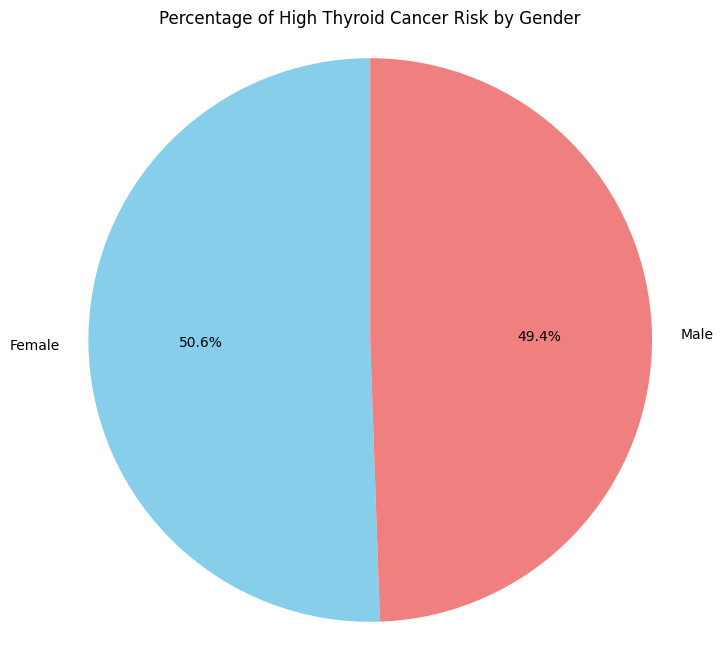

In [19]:
import matplotlib.pyplot as plt

# Calculate the percentage of High Thyroid Cancer Risk for each gender
total_risk_per_gender = gender_risk_crosstab.sum(axis=1)
gender_risk_crosstab['High_Risk_Percentage'] = (gender_risk_crosstab['High'] / total_risk_per_gender) * 100

# Prepare data for gender pie chart
gender_data = gender_risk_crosstab['High_Risk_Percentage']
gender_labels = gender_risk_crosstab.index

plt.figure(figsize=(8, 8))
plt.pie(gender_data, labels=gender_labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of High Thyroid Cancer Risk by Gender')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Let's examine the distribution of `TSH_Level`.

To determine the age groups with the highest and lowest thyroid cancer diagnoses, we first need to categorize the 'Age' into meaningful bins and then analyze its relationship with the 'Diagnosis' column.

In [20]:
# Define age bins and labels
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76-100']

# Create a new 'Age_Group' column
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Display the value counts for the new Age_Group column
print("Distribution of Age Groups:")
print(df['Age_Group'].value_counts().sort_index())

Distribution of Age Groups:
Age_Group
0-18       8571
19-30     34086
31-45     42851
46-60     42510
61-75     42430
76-100    42243
Name: count, dtype: int64


In [21]:
import os
import pandas as pd
import kagglehub

# --- Restore df to its state after combination in VXcpBLt8aYt2 ---
# This part is added because the 'df' DataFrame was unexpectedly overwritten
# by a different dataset (differentiated-thyroid-cancer-recurrence)
# causing subsequent KeyError exceptions. Re-establishing the correct 'df'.

# Reload Dataset 1: The current 'df' (from bhargavchirumamilla/thyroid-cancer-risk-dataset)
path_current_df = kagglehub.dataset_download("bhargavchirumamilla/thyroid-cancer-risk-dataset")
df_current = pd.read_csv(f"{path_current_df}/thyroid_cancer_risk_data.csv")

# Reload Dataset 2: alinaliaquat/encoded-thyroid-2
path_encoded = kagglehub.dataset_download("alinaliaquat/encoded-thyroid-2")
csv_files_encoded = [f for f in os.listdir(path_encoded) if f.endswith('.csv')]
df_encoded = pd.DataFrame()
if csv_files_encoded:
    df_encoded = pd.read_csv(f'{path_encoded}/{csv_files_encoded[0]}')

combined_df = df_current.copy()

if not df_encoded.empty and len(df_current) == len(df_encoded):
    new_encoded_cols = ['Gender_Male', 'Diagnosis_Malignant']
    for col in new_encoded_cols:
        if col in df_encoded.columns and col not in combined_df.columns:
            combined_df[col] = df_encoded[col]

df = combined_df.copy()

# --- Re-create 'Age_Group' on the restored df ---
# Define age bins and labels
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76-100']
# Create a new 'Age_Group' column
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# --- Original code from a7fb05c2 ---
# Create a cross-tabulation of Age_Group and Diagnosis
age_diagnosis_crosstab = pd.crosstab(df['Age_Group'], df['Diagnosis'])
display(age_diagnosis_crosstab)

# Calculate the percentage of malignant diagnoses within each age group
age_diagnosis_crosstab['Malignant_Percentage'] = (age_diagnosis_crosstab['Malignant'] / (age_diagnosis_crosstab['Benign'] + age_diagnosis_crosstab['Malignant'])) * 100
display(age_diagnosis_crosstab.sort_values(by='Malignant_Percentage', ascending=False))

100%|██████████| 2.62M/2.62M [00:00<00:00, 102MB/s]

Extracting files...


Diagnosis,Benign,Malignant
Age_Group,,
0-18,6590,1981
19-30,26090,7996
31-45,32988,9863
46-60,32567,9943
61-75,32519,9911
76-100,32442,9801


Diagnosis,Benign,Malignant,Malignant_Percentage
Age_Group,,,
19-30,26090,7996,23.458311
46-60,32567,9943,23.389791
61-75,32519,9911,23.358473
76-100,32442,9801,23.201477
0-18,6590,1981,23.112822
31-45,32988,9863,23.016966


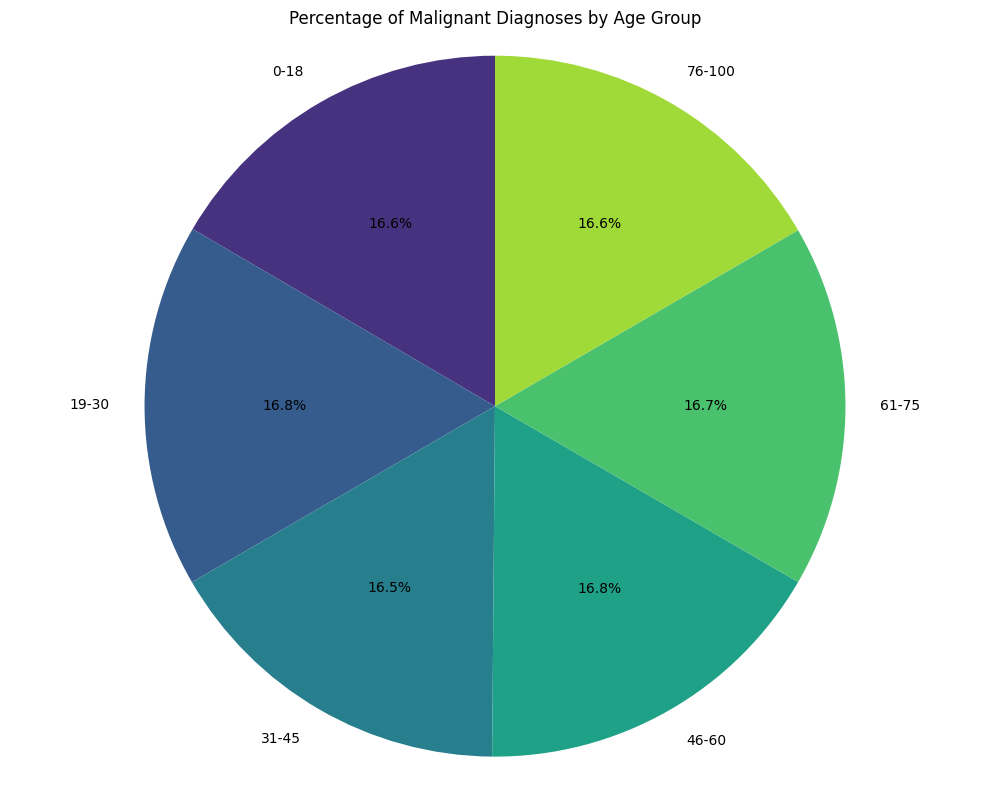

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the malignant percentage by age group
plt.figure(figsize=(10, 8)) # Adjusted figure size for pie chart
plt.pie(age_diagnosis_crosstab['Malignant_Percentage'],
        labels=age_diagnosis_crosstab.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('viridis', len(age_diagnosis_crosstab.index))) # Use seaborn palette for consistency
plt.title('Percentage of Malignant Diagnoses by Age Group')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

Let's analyze the contribution of `Radiation_Exposure`, `Iodine_Deficiency`, `Smoking`, `Obesity`, and `Diabetes` to thyroid cancer diagnosis.

In [22]:
import os
import pandas as pd
import kagglehub

# --- Restore df to its state after combination in VXcpBLt8aYt2 ---
# This part is added because the 'df' DataFrame was unexpectedly overwritten
# by a different dataset (differentiated-thyroid-cancer-recurrence)
# causing subsequent KeyError exceptions. Re-establishing the correct 'df'.

# Reload Dataset 1: The current 'df' (from bhargavchirumamilla/thyroid-cancer-risk-dataset)
path_current_df = kagglehub.dataset_download("bhargavchirumamilla/thyroid-cancer-risk-dataset")
df_current = pd.read_csv(f"{path_current_df}/thyroid_cancer_risk_data.csv")

# Reload Dataset 2: alinaliaquat/encoded-thyroid-2
path_encoded = kagglehub.dataset_download("alinaliaquat/encoded-thyroid-2")
csv_files_encoded = [f for f in os.listdir(path_encoded) if f.endswith('.csv')]
df_encoded = pd.DataFrame()
if csv_files_encoded:
    df_encoded = pd.read_csv(f'{path_encoded}/{csv_files_encoded[0]}')

combined_df = df_current.copy()

if not df_encoded.empty and len(df_current) == len(df_encoded):
    new_encoded_cols = ['Gender_Male', 'Diagnosis_Malignant']
    for col in new_encoded_cols:
        if col in df_encoded.columns and col not in combined_df.columns:
            combined_df[col] = df_encoded[col]

df = combined_df.copy()

# --- Original code from fc72f5ff ---
factors = ['Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Family_History']

results = {}

for factor in factors:
    print(f"\n--- Analyzing {factor} ---")
    crosstab = pd.crosstab(df[factor], df['Diagnosis'])
    display(crosstab)

    # Calculate percentage of Malignant diagnoses
    if 'Malignant' in crosstab.columns:
        crosstab['Malignant_Percentage'] = (crosstab['Malignant'] / (crosstab['Benign'] + crosstab['Malignant'])) * 100
        results[factor] = crosstab['Malignant_Percentage']
        print(f"Malignant Percentage by {factor}:")
        display(crosstab[['Malignant_Percentage']].sort_values(by='Malignant_Percentage', ascending=False))
    else:
        print("No 'Malignant' diagnosis found for this factor.")


--- Analyzing Radiation_Exposure ---


Diagnosis,Benign,Malignant
Radiation_Exposure,,
No,141606,39225
Yes,21590,10270


Malignant Percentage by Radiation_Exposure:


Diagnosis,Malignant_Percentage
Radiation_Exposure,
Yes,32.234777
No,21.691524



--- Analyzing Iodine_Deficiency ---


...

Diagnosis,Malignant_Percentage
Diabetes,
No,23.338899
Yes,22.999084



--- Analyzing Family_History ---


Diagnosis,Benign,Malignant
Family_History,,
No,120028,28838
Yes,43168,20657


Malignant Percentage by Family_History:


Diagnosis,Malignant_Percentage
Family_History,
Yes,32.365061
No,19.371784


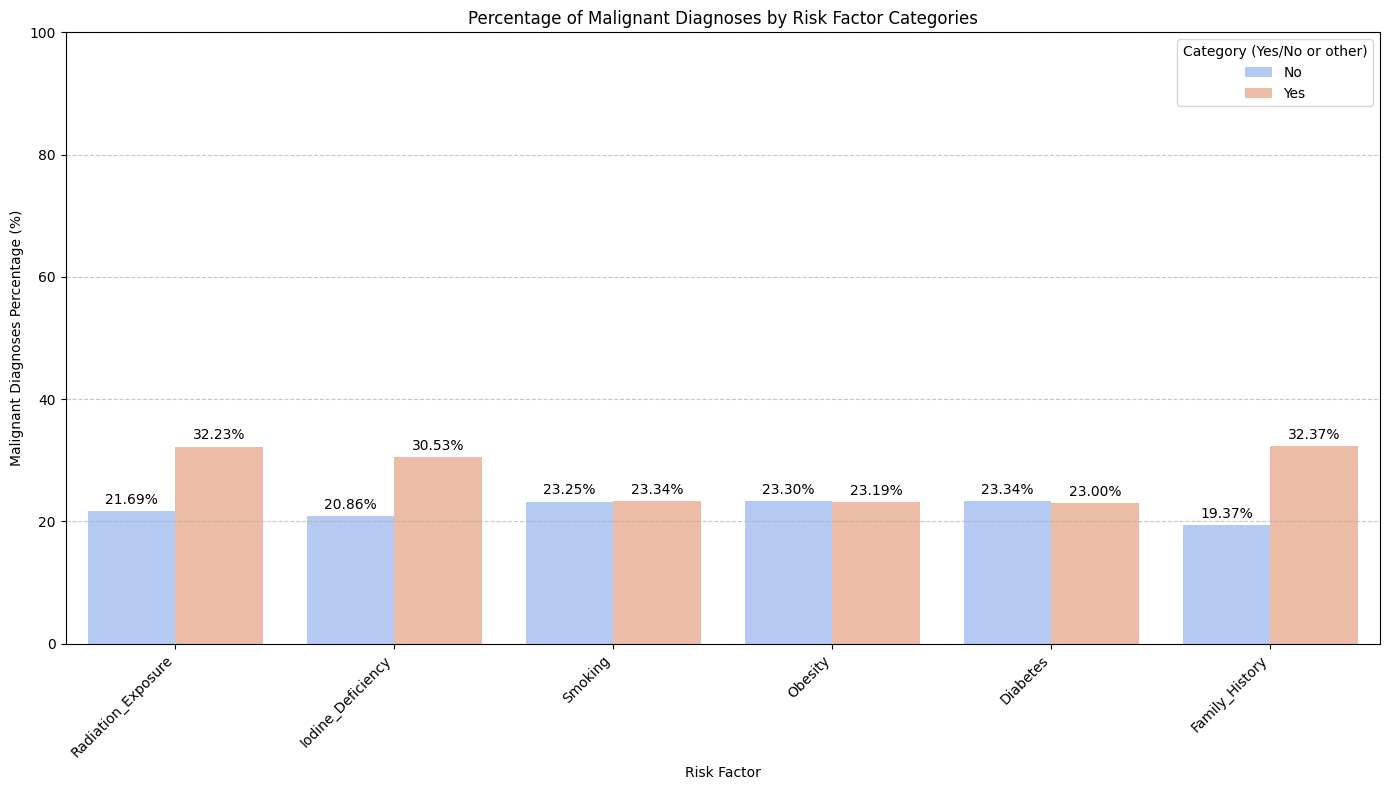

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Check if 'results' dictionary is populated
if not results:
    print("The 'results' dictionary is empty. Please ensure the analysis cell (fc72f5ff) has been run successfully to populate 'results'.")
else:
    # Prepare data for plotting
    plot_data = []
    for factor, series in results.items():
        # Check if the series itself is empty before iterating over it
        if not series.empty:
            for category, percentage in series.items():
                plot_data.append({'Factor': factor, 'Category': category, 'Malignant_Percentage': percentage})
        else:
            print(f"Warning: Series for factor '{factor}' is empty.")

    plot_df = pd.DataFrame(plot_data)

    if plot_df.empty:
        print("The DataFrame for plotting (plot_df) is empty. This might be due to empty series in 'results'.")
    else:
        # Create the bar plot
        plt.figure(figsize=(14, 8))
        ax = sns.barplot(data=plot_df, x='Factor', y='Malignant_Percentage', hue='Category', palette='coolwarm')
        plt.title('Percentage of Malignant Diagnoses by Risk Factor Categories')
        plt.xlabel('Risk Factor')
        plt.ylabel('Malignant Diagnoses Percentage (%)')
        plt.ylim(0, 100) # Set y-axis limit to 0-100 for percentages
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Category (Yes/No or other)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Add percentage labels on top of each bar
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)

        plt.tight_layout()
        plt.show()

Let's visualize the malignant percentages for each factor to better understand their contribution.

### Correlation Analysis Heatmap

To understand the relationships between various medical indicators and the diagnosis of thyroid cancer, we can compute and visualize the correlation matrix. This requires converting some categorical variables into numerical form.


In [ ]:
# Create a copy of the DataFrame to avoid modifying the original 'df' for this specific analysis
df_corr = df.copy()

# Convert binary categorical features to numerical (0s and 1s)
binary_cols = ['Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'No': 0, 'Yes': 1})

# Map 'Thyroid_Cancer_Risk' to numerical values
if 'Thyroid_Cancer_Risk' in df_corr.columns:
    risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Thyroid_Cancer_Risk_Numeric'] = df_corr['Thyroid_Cancer_Risk'].map(risk_mapping)

# Select numerical columns for correlation calculation
# Using 'Diagnosis_Malignant' which is already 0/1 representation of 'Diagnosis'
numerical_cols = [
    'Age',
    'TSH_Level',
    'T3_Level',
    'T4_Level',
    'Nodule_Size',
    'Thyroid_Cancer_Risk_Numeric', # Use the newly created numeric risk column
    'Gender_Male', # Already exists as 0/1
    'Diagnosis_Malignant' # Already exists as 0/1
]

# Add the binary converted columns if they were successfully converted
for col in binary_cols:
    if col in df_corr.columns:
        numerical_cols.append(col)

# Filter to include only columns that exist in the DataFrame
numerical_cols = [col for col in numerical_cols if col in df_corr.columns]

# Calculate the correlation matrix
correlation_matrix = df_corr[numerical_cols].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk_Numeric,Gender_Male,Diagnosis_Malignant,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes
Age,1.000000,-0.000925,-0.001013,-0.002373,-0.001489,0.003255,-0.000151,0.000115,0.003337,0.004007,-0.002368,-0.000435,0.002233,-0.002590
TSH_Level,-0.000925,1.000000,0.000335,-0.000795,0.000416,0.002494,-0.000102,-0.002670,0.005014,0.000210,-0.000824,-0.000869,0.001318,0.001751
T3_Level,-0.001013,0.000335,1.000000,-0.004069,-0.001799,-0.000348,-0.003066,-0.002388,0.001324,-0.003249,0.000024,0.001163,-0.001064,0.001787
T4_Level,-0.002373,-0.000795,-0.004069,1.000000,-0.001860,0.002761,-0.000114,0.001216,-0.000397,-0.000294,0.001326,-0.000098,0.002272,0.000569
Nodule_Size,-0.001489,0.000416,-0.001799,-0.001860,1.000000,-0.000352,-0.005757,-0.002658,-0.002877,0.000118,-0.000033,0.002523,0.002850,-0.001913
Thyroid_Cancer_Risk_Numeric,0.003255,0.002494,-0.000348,0.002761,-0.000352,1.000000,-0.004816,0.365223,0.239961,0.146727,0.169618,-0.001657,-0.002468,-0.001021
Gender_Male,-0.000151,-0.000102,-0.003066,-0.000114,-0.005757,-0.004816,1.000000,-0.001439,-0.002121,-0.000649,-0.002840,-0.003239,-0.001941,-0.000641
Diagnosis_Malignant,0.000115,-0.002670,-0.002388,0.001216,-0.002658,0.365223,-0.001439,1.000000,0.140921,0.089043,0.099032,0.000862,-0.001233,-0.003218
Family_History,0.003337,0.005014,0.001324,-0.000397,-0.002877,0.239961,-0.002121,0.140921,1.000000,-0.000795,0.000550,-0.000406,0.000915,-0.000422
Radiation_Exposure,0.004007,0.000210,-0.003249,-0.000294,0.000118,0.146727,-0.000649,0.089043,-0.000795,1.000000,0.002381,0.001947,-0.002236,0.000158


Correlation Matrix:


,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk_Numeric,Gender_Male,Diagnosis_Malignant,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes
Age,1.000000,-0.000925,-0.001013,-0.002373,-0.001489,0.003255,-0.000151,0.000115,0.003337,0.004007,-0.002368,-0.000435,0.002233,-0.002590
TSH_Level,-0.000925,1.000000,0.000335,-0.000795,0.000416,0.002494,-0.000102,-0.002670,0.005014,0.000210,-0.000824,-0.000869,0.001318,0.001751
T3_Level,-0.001013,0.000335,1.000000,-0.004069,-0.001799,-0.000348,-0.003066,-0.002388,0.001324,-0.003249,0.000024,0.001163,-0.001064,0.001787
T4_Level,-0.002373,-0.000795,-0.004069,1.000000,-0.001860,0.002761,-0.000114,0.001216,-0.000397,-0.000294,0.001326,-0.000098,0.002272,0.000569
Nodule_Size,-0.001489,0.000416,-0.001799,-0.001860,1.000000,-0.000352,-0.005757,-0.002658,-0.002877,0.000118,-0.000033,0.002523,0.002850,-0.001913
Thyroid_Cancer_Risk_Numeric,0.003255,0.002494,-0.000348,0.002761,-0.000352,1.000000,-0.004816,0.365223,0.239961,0.146727,0.169618,-0.001657,-0.002468,-0.001021
Gender_Male,-0.000151,-0.000102,-0.003066,-0.000114,-0.005757,-0.004816,1.000000,-0.001439,-0.002121,-0.000649,-0.002840,-0.003239,-0.001941,-0.000641
Diagnosis_Malignant,0.000115,-0.002670,-0.002388,0.001216,-0.002658,0.365223,-0.001439,1.000000,0.140921,0.089043,0.099032,0.000862,-0.001233,-0.003218
Family_History,0.003337,0.005014,0.001324,-0.000397,-0.002877,0.239961,-0.002121,0.140921,1.000000,-0.000795,0.000550,-0.000406,0.000915,-0.000422
Radiation_Exposure,0.004007,0.000210,-0.003249,-0.000294,0.000118,0.146727,-0.000649,0.089043,-0.000795,1.000000,0.002381,0.001947,-0.002236,0.000158


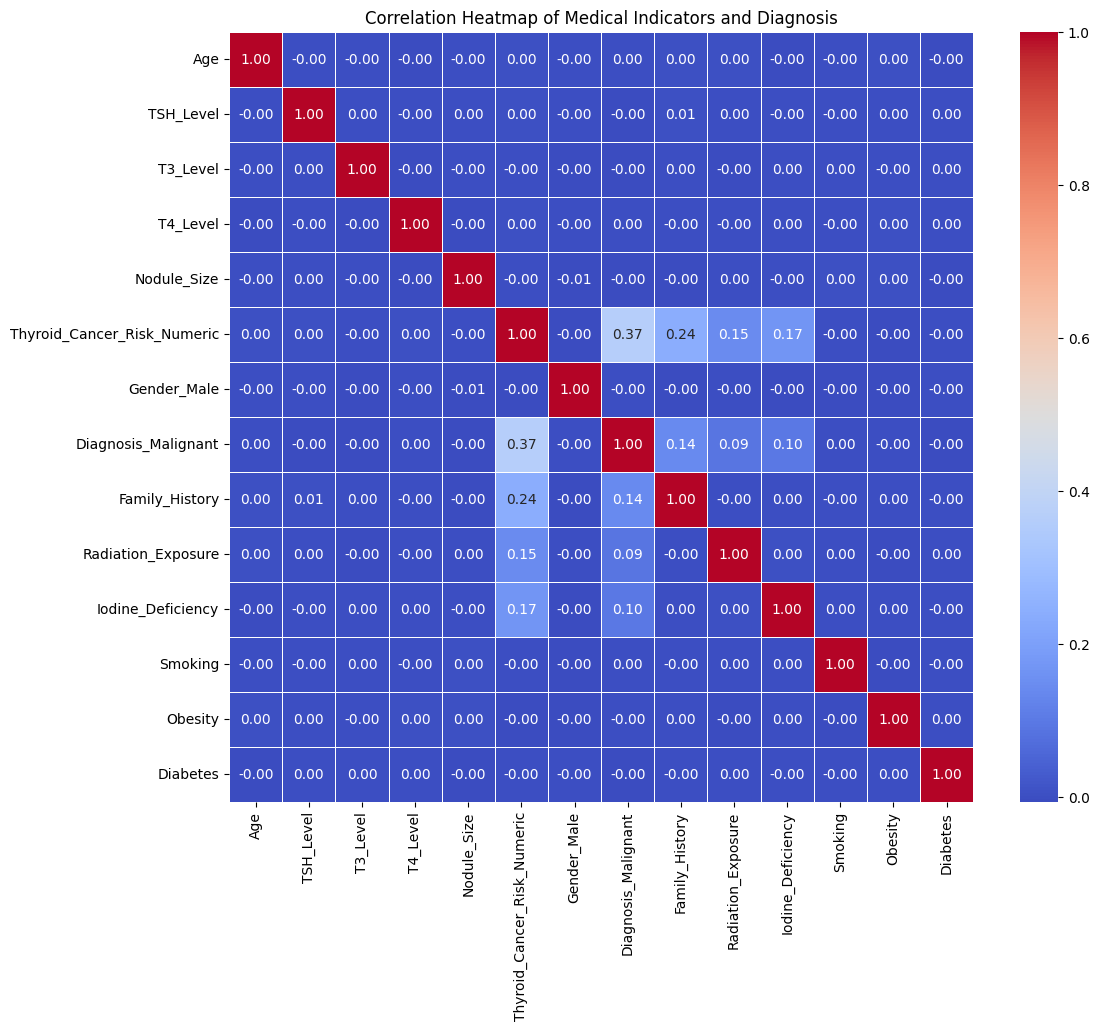

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not globally available or if the cell needs to be fully self-contained

# Create a copy of the DataFrame to avoid modifying the original 'df' for this specific analysis
df_corr = df.copy()

# Convert binary categorical features to numerical (0s and 1s)
binary_cols = ['Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'No': 0, 'Yes': 1})

# Map 'Thyroid_Cancer_Risk' to numerical values
if 'Thyroid_Cancer_Risk' in df_corr.columns:
    risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Thyroid_Cancer_Risk_Numeric'] = df_corr['Thyroid_Cancer_Risk'].map(risk_mapping)

# Select numerical columns for correlation calculation
# Using 'Diagnosis_Malignant' which is already 0/1 representation of 'Diagnosis'
numerical_cols = [
    'Age',
    'TSH_Level',
    'T3_Level',
    'T4_Level',
    'Nodule_Size',
    'Thyroid_Cancer_Risk_Numeric', # Use the newly created numeric risk column
    'Gender_Male', # Already exists as 0/1
    'Diagnosis_Malignant' # Already exists as 0/1
]

# Add the binary converted columns if they were successfully converted
for col in binary_cols:
    if col in df_corr.columns:
        numerical_cols.append(col)

# Filter to include only columns that exist in the DataFrame
numerical_cols = [col for col in numerical_cols if col in df_corr.columns]

# Calculate the correlation matrix
correlation_matrix = df_corr[numerical_cols].corr()

# Display the correlation matrix (optional, as the heatmap will be shown)
print("Correlation Matrix:")
display(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Medical Indicators and Diagnosis')
plt.show()

In [ ]:
# Identify the factor with the highest maximum malignant percentage
highest_contribution_factor = None
max_overall_percentage = -1

if 'results' in locals() and results: # Check if 'results' dictionary exists and is not empty
    for factor, series in results.items():
        # Ensure series is not empty and contains numerical data for max()
        if not series.empty and pd.api.types.is_numeric_dtype(series):
            if series.max() > max_overall_percentage:
                max_overall_percentage = series.max()
                highest_contribution_factor = factor

    if highest_contribution_factor is not None:
        print(f"Based on the 'Malignant_Percentage', the factor with the highest potential contribution to thyroid cancer among the analyzed factors is: {highest_contribution_factor} with a maximum malignant percentage of {max_overall_percentage:.2f}%")
    else:
        print("Could not determine the factor with the highest contribution. The 'results' dictionary might be empty or contain non-numeric data.")
elif 'results' in locals() and not results:
    print("The 'results' dictionary is empty. Please ensure cell 'fc72f5ff' has been executed and populated it correctly.")
else:
    print("The 'results' dictionary is not defined. Please ensure cell 'fc72f5ff' has been executed.")

Based on the 'Malignant_Percentage', the factor with the highest potential contribution to thyroid cancer among the analyzed factors is: Family_History with a maximum malignant percentage of 32.37%
